In [1]:
# Membuat direktori raw dan processed di HDFS
!hdfs dfs -mkdir -p /user/zhio/ecommerce/raw
!hdfs dfs -mkdir -p /user/zhio/ecommerce/processed

# Verifikasi struktur direktori
!hdfs dfs -ls /user/zhio/ecommerce

Found 2 items
drwxr-xr-x   - zhio supergroup          0 2026-09-05 13:28 /user/zhio/ecommerce/processed
drwxr-xr-x   - zhio supergroup          0 2026-09-05 13:28 /user/zhio/ecommerce/raw


In [2]:
# Upload ketiga berkas CSV cabang ke direktori raw di HDFS
!hdfs dfs -put transaksi_magelang.csv /user/zhio/ecommerce/raw/
!hdfs dfs -put transaksi_yogyakarta.csv /user/zhio/ecommerce/raw/
!hdfs dfs -put transaksi_semarang.csv /user/zhio/ecommerce/raw/

# Verifikasi keberadaan berkas dan ukurannya
!hdfs dfs -ls -h /user/zhio/ecommerce/raw

Found 3 items
-rw-r--r--   1 zhio supergroup     12.0 K 2026-09-05 13:29 /user/zhio/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 zhio supergroup     11.9 K 2026-09-05 13:29 /user/zhio/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 zhio supergroup     12.4 K 2026-09-05 13:29 /user/zhio/ecommerce/raw/transaksi_yogyakarta.csv


In [3]:
import pandas as pd
import subprocess
from io import StringIO

# Fungsi pembaca stream berkas langsung dari HDFS via hdfs dfs -cat
def baca_hdfs(path_hdfs):
    output = subprocess.check_output(f"hdfs dfs -cat {path_hdfs}", shell=True).decode('utf-8')
    return pd.read_csv(StringIO(output))

# Membaca ketiga berkas langsung dari direktori raw HDFS (bukan disk lokal)
df_magelang = baca_hdfs("/user/zhio/ecommerce/raw/transaksi_magelang.csv")
df_jogja = baca_hdfs("/user/zhio/ecommerce/raw/transaksi_yogyakarta.csv")
df_semarang = baca_hdfs("/user/zhio/ecommerce/raw/transaksi_semarang.csv")

# Menggabungkan ketiga data kota menjadi satu DataFrame
df_gabungan = pd.concat([df_magelang, df_jogja, df_semarang], ignore_index=True)

# Tampilkan sampel data
display(df_gabungan.head())

# Verifikasi keberadaan transaksi dari ketiga kota
print("\nVerifikasi Jumlah Transaksi per Kota:")
print(df_gabungan['kota'].value_counts())

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang



Verifikasi Jumlah Transaksi per Kota:
kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


In [4]:
# 1. Menambahkan kolom total_pendapatan
df_gabungan['total_pendapatan'] = df_gabungan['unit_terjual'] * df_gabungan['harga_satuan']

# 2. Tabel ringkasan groupby: total pendapatan per kota dan kategori
ringkasan_kota_kategori = df_gabungan.groupby(['kota', 'kategori'])['total_pendapatan'].sum().reset_index()

print("--- Tabel Ringkasan Pendapatan per Kota & Kategori ---")
display(ringkasan_kota_kategori)

# 3. Simpan kedua hasil ke berkas CSV lokal
df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
ringkasan_kota_kategori.to_csv("ringkasan_kota_kategori.csv", index=False)
print("\nBerkas CSV lokal berhasil disimpan.")

# 4. Unggah kedua berkas olahan ke direktori processed di HDFS (-f untuk overwrite jika ada)
!hdfs dfs -put -f data_gabungan_bersih.csv /user/zhio/ecommerce/processed/
!hdfs dfs -put -f ringkasan_kota_kategori.csv /user/zhio/ecommerce/processed/

# 5. Verifikasi isi direktori processed beserta ukuran berkasnya
!hdfs dfs -ls -h /user/zhio/ecommerce/processed

--- Tabel Ringkasan Pendapatan per Kota & Kategori ---


,kota,kategori,total_pendapatan
0,Magelang,Elektronik,18775000
1,Magelang,Fashion,27750000
2,Magelang,Kesehatan & Kecantikan,17375000
3,Magelang,Makanan & Minuman,17525000
4,Magelang,Rumah Tangga,12200000
5,Semarang,Elektronik,21425000
6,Semarang,Fashion,26425000
7,Semarang,Kesehatan & Kecantikan,13525000
8,Semarang,Makanan & Minuman,19750000
9,Semarang,Rumah Tangga,10975000



Berkas CSV lokal berhasil disimpan.
Found 2 items
-rw-r--r--   1 zhio supergroup     40.3 K 2026-09-05 13:31 /user/zhio/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 zhio supergroup        530 2026-09-05 13:31 /user/zhio/ecommerce/processed/ringkasan_kota_kategori.csv


### Bagian E.1: Dokumentasi Struktur HDFS di NameNode Web UI
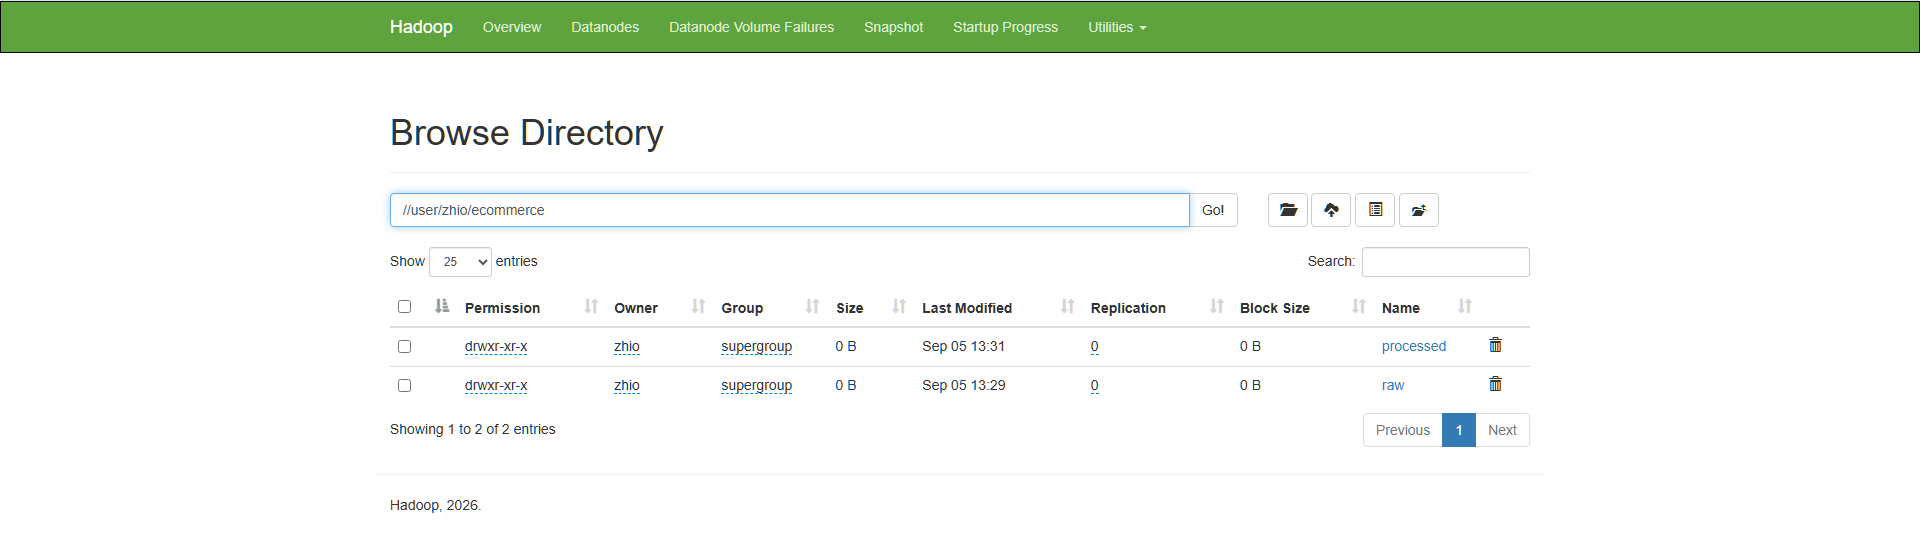

### Bagian E.2: Refleksi Arsitektur Data HDFS

Pemisahan antara direktori raw (data mentah) dan processed (data olahan) pada sistem berkas terdistribusi HDFS memberikan keunggulan arsitektural fundamental dalam ekosistem Big Data, antara lain:

1. Integritas dan Sifat Immutability Data: Direktori raw bertindak sebagai single source of truth historis yang bersifat kekal (immutable). Apabila terjadi galat logika pemrosesan, kegagalan pipeline, atau perubahan formula analitik di masa mendatang, teknisi data dapat melakukan komputasi ulang (re-processing) dari awal kapan saja tanpa risiko kehilangan data asli transaksi.
2. Efisiensi Konsumsi Data: Tim analis bisnis, pemodelan machine learning, dan dashboard business intelligence (BI) dapat langsung mengonsumsi data yang sudah bersih dan teragregasi di direktori processed, tanpa perlu membebani klaster untuk memilah ribuan berkas transaksi mentah berulang kali.
3. Tata Kelola dan Keamanan (Data Governance): Memudahkan pengaturan izin akses (permission). Akses ke data mentah sensitif dapat dibatasi ketat, sementara folder olahan dapat dibuka secara aman untuk kebutuhan tim hilir (downstream) tanpa khawatir terjadi penghapusan atau modifikasi berkas induk secara tidak sengaja.